In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
plt.rcParams['font.family'] = 'Arial'

In [2]:
df = pd.read_csv('../figure5/data/matmat_benchmark.tsv', sep='\t')
df

,method,n_vectors,chrom,load_time,matmat_type,matmat_time,max_memory
0,linarg,1,1,34.716832,right,6.140907,2178.472656
1,linarg,1,11,20.771607,right,3.638333,2281.226562
2,linarg,1,21,6.759565,right,1.035663,2146.566406
3,linarg,2,1,35.407900,right,31.462085,2149.242188
4,linarg,2,11,23.021856,right,18.302428,2231.308594
...,...,...,...,...,...,...,...
79,scipy,1,11,692.521633,left,181.009868,10233.984375
80,scipy,1,21,201.544423,left,60.671373,7840.933594
81,xsi,1,1,NaN,right,238.575000,4079.920000
82,xsi,1,11,NaN,right,1253.706000,3967.590000


/var/folders/75/tn_w8_tx70dfp53nnb6hyk6h0000gn/T/ipykernel_28358/3882255762.py:49: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 3e5)


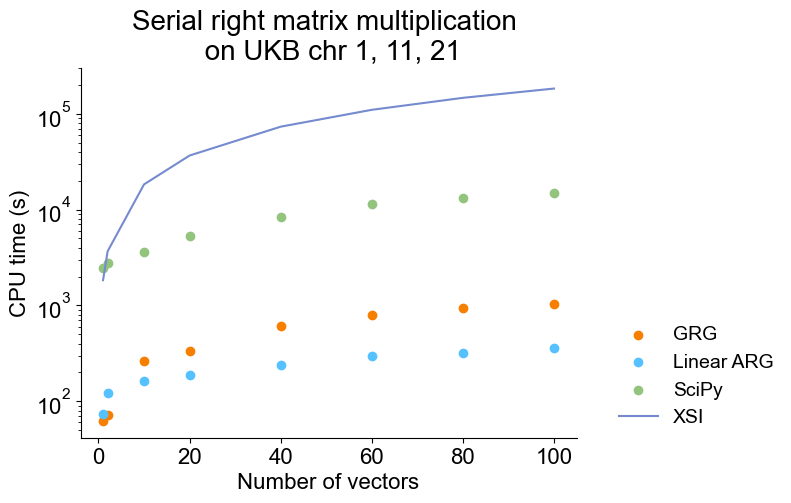

In [3]:
df_total = pd.DataFrame(columns=['method', 'n_vectors', 'total_time'])

for n_vectors in [1, 2, 10, 20, 40, 60, 80, 100]:
    for method in ['linarg', 'grg', 'scipy', 'xsi']:
        if method == 'xsi':
            df_filt = df[(df.method==method) & (df.matmat_type=='right')]
            total_time = np.sum(df_filt.matmat_time) * n_vectors
        else:
            df_filt = df[(df.method==method) & (df.matmat_type=='right') & (df.n_vectors==n_vectors)]
            total_time = np.sum(df_filt.load_time) + np.sum(df_filt.matmat_time)
        df_total.loc[len(df_total)] = [method, n_vectors, total_time]

color_map = {
    'grg': '#F77F00', # orange
    'linarg': '#56C1FF', # blue
    'xsi': '#758acf', # purple
    'scipy': '#93c47d', # green   
}

name_map = {
    'grg': 'GRG', # orange
    'linarg': 'Linear ARG', # blue
    'xsi': 'XSI', # purple
    'scipy': 'SciPy', # green   
}


plt.rcParams['font.family'] = 'Arial'

for method in ['grg', 'linarg', 'scipy', 'xsi']:
    res_filt = df_total[df_total.method==method]
    if method != 'xsi':
        plt.scatter(res_filt.n_vectors, res_filt.total_time, label=name_map[method], color=color_map[method])
    else:
        plt.plot(res_filt.n_vectors, res_filt.total_time, label=name_map[method], color=color_map[method])
plt.yscale('log')
plt.xlabel('Number of vectors', fontsize=16)
plt.ylabel('CPU time (s)', fontsize=16)
plt.tick_params(axis='both', labelsize=16)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.title('Serial right matrix multiplication \n on UKB chr 1, 11, 21', fontsize=20)
plt.legend(
    frameon=False,
    fontsize=14,
    loc='upper left',
    bbox_to_anchor=(1.05, 0.35)
)
plt.ylim(0, 3e5)
plt.show()